In [2]:
import jax.numpy as jnp 
import jax
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import diffrax
import equinox

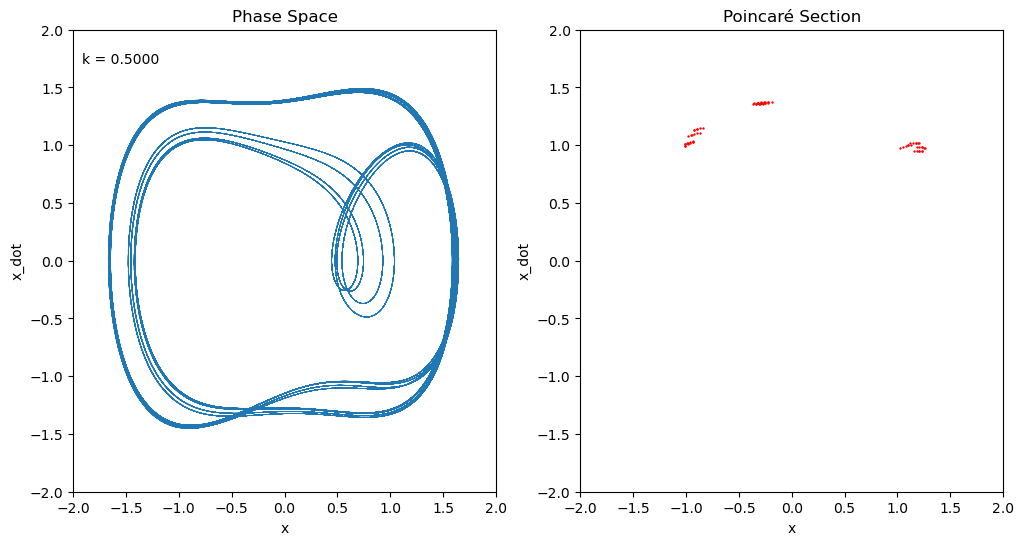

In [18]:
# Constants
C = 0.0
k = 0.575
omega = 1.2
gamma = 1.0
alpha = 1.0
beta = -1.0

#pointcare time interval
T = 2 * jnp.pi /(omega)


#variable to sweep across, should match name from constants
varToTest = "k"
values = jnp.linspace(0.5, .65, 100)



def dx_dt(t, x, params):
    #Basic Duffing ODE, added a term 'C' to show constant slope.
    C = params["C"]
    k = params["k"]
    omega = params["omega"]
    gamma = params["gamma"]
    alpha = params["alpha"]
    beta = params["beta"]

    return jnp.array([
        x[1],
        -beta*x[0]
        - k*x[1]
        - alpha*x[0]**3
        + gamma*jnp.cos(omega*t)
        + C
    ])

#Get our ODE solver setup
term = diffrax.ODETerm(dx_dt)
solver = diffrax.Tsit5()
y0 = jnp.array([0.0, 1.0])
ts = jnp.linspace(4000, 5000, 10000)

def solve_single(value):
    #Solde the ODE for one snapshot of constants
    params = {"C":C,"k":k,"omega":omega,"gamma":gamma,"alpha":alpha,"beta":beta}
    params[varToTest] = value  

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=5000,
        dt0=0.05,
        y0=y0,
        args=params,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps=1_000_000,
    )
    return sol.ys

#call all the jax stuff up to now
batched_solve = jax.vmap(solve_single)
solutions = batched_solve(values)[:,1000:,] #throw away first 1000 points to focus on steady state operation

#matplotlib junk
fig, (ax_phase, ax_poincare) = plt.subplots(1, 2, figsize=(12,6))
phase_line, = ax_phase.plot([], [], lw=0.5)
poincare_scatter = ax_poincare.scatter(
    [], [],
    s=2,           
    c="red",       
    marker=".",    
)

ax_phase.set_title("Phase Space")
ax_phase.set_xlabel("x")
ax_phase.set_ylabel("x_dot")
ax_poincare.set_title("Poincaré Section")
ax_poincare.set_xlabel("x")
ax_poincare.set_ylabel("x_dot")
ax_phase.set_xlim(-2,2)
ax_phase.set_ylim(-2,2)
ax_poincare.set_xlim(-2,2)
ax_poincare.set_ylim(-2,2)
param_text = ax_phase.text( #Set up persistant text on top of plot we can iterate with the constan's value
    0.02, 0.95, "",
    transform=ax_phase.transAxes,
    verticalalignment="top"
)

ts_array = ts[1000:]
poincare_times = jnp.arange(ts_array[0], ts_array[-1], T)
poincare_indices = jnp.searchsorted(ts_array, poincare_times)


def update(frame):
    #Function required for animation, just goes through and crunches all the numbers for one frame of the animation
    current_value = values[frame]
    trajectory = solutions[frame]

    phase_line.set_data(
        trajectory[:,0],
        trajectory[:,1]
    )

    poincare = trajectory[poincare_indices][100:]

    poincare_scatter.set_offsets(
        jnp.column_stack((poincare[:,0], poincare[:,1]))
    )

    param_text.set_text(
        f"{varToTest} = {float(current_value):.4f}"
    )

    return phase_line, poincare_scatter, param_text

ani = animation.FuncAnimation(
    #Create a matplotlib animation
    fig, update, frames=100, interval=50
)

ani.save("duffing_animationVark.mp4", writer="ffmpeg", fps=10)